# Neural network: whole-election validation across historical periods

Compare a **32/16 ReLU neural network**, cross-entropy loss and ten-seed probability ensembles across three historical training windows. All constituencies from the validation election are held out from weight updates and preprocessing. This notebook does not change or import pipeline model code, download data, or read the 2024 test file.

| Weight-update elections | Early-stopping election |
|---|---|
| All available elections through 2015 | 2017 |
| All available elections through 2005 | 2010 |
| All available elections through 1997 | 2001 |

Learning rates use matched seeds and batch orders. Each network restores its lowest qualifying validation cross-entropy checkpoint. The learning-rate comparison uses **ensemble validation log loss**, averaged equally across the three elections. No model weights are averaged across historical windows.

**Interpretation:** these are development/validation results, not independent forecasting tests. Validation outcomes choose both checkpoints and learning rates. Ten seeds measure training variability, not ten independent electoral environments. Later historical windows include elections used for validation in earlier windows; the windows are not independent samples. Next-election development evaluation is enabled as requested; consequently 2019 is no longer an untouched later comparison.

In [1]:
from pathlib import Path
from typing import Any, TypedDict
import copy, hashlib, json, platform, time
import numpy as np
from numpy.typing import NDArray
import pandas as pd
from scipy import sparse
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "TEST_TRAIN/train.csv").exists())
DATA_PATH = ROOT / "TEST_TRAIN/train.csv"
OUTPUT_DIR = ROOT / "Analysis and model development/nn_whole_election_validation_results"
SEEDS = tuple(range(101223, 101233))
LEARNING_RATES = (0.01, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0)
HIDDEN_SIZES = (32, 16)
BATCH_SIZE = 64
MAX_EPOCHS = 1000
PATIENCE = 20
MIN_DELTA = 0.0
# CPU threads kept small because these networks and batches are small.
torch.set_num_threads(1)
WINDOWS = [(2015, 2017, 2019), (2005, 2010, 2015), (1997, 2001, 2005)]
# Optional next-election development evaluation; never used to rank learning rates.
EVALUATE_NEXT_ELECTION = True
FEATURE_COLUMNS = [
    "country/region",
    "previous_majority_proportion",
    "previous_winner",
    "Conservative",
    "Labour",
    "LD",
    "incumbent",
    "previous_con_share",
    "previous_lib_share",
    "previous_lab_share",
    "previous_natSW_share",
    "projected_con_share",
    "projected_lib_share",
    "projected_lab_share",
]
CATEGORICAL_COLUMNS = ["country/region", "previous_winner", "incumbent"]
NUMERIC_COLUMNS = [
    column for column in FEATURE_COLUMNS if column not in CATEGORICAL_COLUMNS
]




/home/codespace/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-tcsy1ade because there was an issue with the default path (/home/codespace/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Data and split checks

All labelled rows are retained, including rows with missing predictors. Numeric medians, scaling and categorical encoding are fitted on weight-update rows only. The output class mapping is learned from those rows; a validation class absent from training raises an explicit error. Current-election results, constituency identifiers and election year are not predictors.

In [2]:
data = pd.read_csv(DATA_PATH)
data["election"] = pd.to_numeric(data["election"], errors="raise")
assert data["election"].notna().all()
assert data["winner"].notna().all(), "Resolve missing outcome labels before running."
assert set(FEATURE_COLUMNS).issubset(data.columns)
split_records = []
for cutoff, validation_year, evaluation_year in WINDOWS:
    training = data.loc[data.election <= cutoff]
    validation = data.loc[data.election == validation_year]
    assert not training.empty and not validation.empty
    assert training.election.max() == cutoff and cutoff < validation_year < evaluation_year
    assert set(validation.winner).issubset(set(training.winner)), "Validation includes an unseen class."
    split_records.append(dict(train_through=cutoff, training_elections=sorted(training.election.unique().tolist()),
                              training_rows=len(training), validation_year=validation_year,
                              validation_rows=len(validation)))
display(pd.DataFrame(split_records))


,train_through,training_elections,training_rows,validation_year,validation_rows
0,2015,"[1987, 1992, 1997, 2001, 2005, 2010, 2015]",4441,2017,632
1,2005,"[1987, 1992, 1997, 2001, 2005]",3177,2010,632
2,1997,"[1987, 1992, 1997]",1908,2001,641


## Model and training

SGD has no momentum or weight decay. Cross-entropy consumes raw logits; softmax is applied only for probability predictions. Patience is 20 epochs with no validation-loss improvement, with a 1,000-epoch safety cap. Runs reaching the cap are flagged for review rather than treated as converged. Architecture, patience and preprocessing stay fixed across learning rates and periods.

In [3]:
def make_preprocessor() -> ColumnTransformer:
    """Create preprocessing to fit on training rows and reuse for prediction."""
    return ColumnTransformer([
        # Fill missing numbers with training medians, then centre and scale them.
        # Keep even entirely missing columns so the feature layout stays stable.
        ("numeric", Pipeline([
            ("impute", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("scale", StandardScaler()),
        ]), NUMERIC_COLUMNS),
        ("categorical", Pipeline([
            # Treat missing categories as a named category. One-hot encoding makes
            # a separate indicator column for each category seen during fitting;
            # unseen categories at prediction time get all-zero indicators.
            ("impute", SimpleImputer(
                strategy="constant", fill_value="__MISSING__", keep_empty_features=True
            )),
            ("encode", OneHotEncoder(handle_unknown="ignore")),
        ]), CATEGORICAL_COLUMNS),
    ])


def as_features(matrix: NDArray[Any] | sparse.spmatrix) -> torch.Tensor:
    """Convert sklearn's feature matrix into a dense float32 PyTorch tensor."""
    # One-hot encoding can produce sparse matrices; these linear layers need dense input.
    if sparse.issparse(matrix):
        matrix = matrix.toarray()
    array = np.asarray(matrix, dtype=np.float32)
    # Fail early if preprocessing leaves NaN or infinite values in the predictors.
    if not np.isfinite(array).all():
        raise ValueError("Preprocessed predictors contain non-finite values.")
    return torch.from_numpy(array)


class NeuralNetwork(nn.Module):
    """CPU classifier trained with cross-entropy on raw logits."""

    def __init__(self, input_dim: int, num_classes: int) -> None:
        super().__init__()
        layers = []
        # Each linear layer learns weighted combinations of its inputs. ReLU sets
        # negative outputs to zero, letting the network learn nonlinear patterns.
        for width in HIDDEN_SIZES:
            layers.extend([nn.Linear(input_dim, width), nn.ReLU()])
            input_dim = width
        # Output raw logits for cross-entropy, which applies log-softmax internally.
        # Convert logits to probabilities with softmax only for evaluation.
        layers.append(nn.Linear(input_dim, num_classes))
        self.layers = nn.Sequential(*layers)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        # Calling network(X) passes the rows through every layer in sequence.
        return self.layers(X)


class TrainingRecord(TypedDict):
    """Diagnostics for one seeded training run."""

    seed: int
    learning_rate: float
    best_epoch: int | None
    stopping_epoch: int
    best_validation_loss: float | None



def _train_network(
    training: pd.DataFrame, validation: pd.DataFrame | None,
    label_encoder: LabelEncoder, seed: int, epochs: int, learning_rate: float,
) -> tuple[NeuralNetwork, ColumnTransformer, TrainingRecord]:
    """Restore the best checkpoint with validation; otherwise run exactly epochs."""
    preprocessor = make_preprocessor()
    # Learn preprocessing only from training rows to avoid leaking validation data.
    x_train = as_features(preprocessor.fit_transform(training[FEATURE_COLUMNS]))
    # Cross-entropy expects integer class indices and raw network logits.
    y_train = torch.tensor(
        label_encoder.transform(training["winner"]), dtype=torch.long,
    )
    if validation is not None:
        x_validation = as_features(preprocessor.transform(validation[FEATURE_COLUMNS]))
        y_validation = torch.tensor(
            label_encoder.transform(validation["winner"]), dtype=torch.long,
        )

    # Keep initialisation reproducible without changing the caller's RNG state.
    with torch.random.fork_rng(devices=[]):
        torch.manual_seed(seed)
        network = NeuralNetwork(x_train.shape[1], len(label_encoder.classes_))
        # Shuffle paired features and labels into batches with a separately seeded
        # generator, making the batch order reproducible for this run.
        loader = DataLoader(
            TensorDataset(x_train, y_train), batch_size=BATCH_SIZE, shuffle=True,
            generator=torch.Generator().manual_seed(seed), num_workers=0,
        )
        optimizer = torch.optim.SGD(network.parameters(), lr=learning_rate, momentum=0.0)
        # Average negative log probability of the winning class over rows.
        criterion = nn.CrossEntropyLoss()
        best_loss = float("inf")
        best_epoch = 0
        best_state = None
        stale_epochs = 0
        for epoch in range(1, epochs + 1):
            network.train()
            for x_batch, y_batch in loader:
                # Clear old gradients, measure this batch's error, differentiate
                # it with respect to the weights, then apply an SGD update.
                optimizer.zero_grad()
                loss = criterion(network(x_batch), y_batch)
                if not torch.isfinite(loss).item():
                    raise RuntimeError(f"Non-finite training loss for seed {seed}, epoch {epoch}")
                loss.backward()
                optimizer.step()
            if validation is None:
                # Refitting uses a fixed duration, with no early-stopping check.
                continue
            # Evaluate held-out rows after each epoch without updating the weights.
            network.eval()
            with torch.inference_mode():
                validation_loss = criterion(
                    network(x_validation), y_validation
                ).item()
            if not np.isfinite(validation_loss):
                raise RuntimeError(f"Non-finite validation loss for seed {seed}, epoch {epoch}")
            if validation_loss < best_loss - MIN_DELTA:
                best_loss = validation_loss
                best_epoch = epoch
                # Copy the weights so later updates cannot change this checkpoint.
                best_state = copy.deepcopy(network.state_dict())
                stale_epochs = 0
            else:
                stale_epochs += 1
            if stale_epochs >= PATIENCE:
                break
        if validation is not None:
            # Use the best qualifying checkpoint, which can precede the stopping epoch.
            network.load_state_dict(best_state)
        network.eval()
    # Keep diagnostics for inspecting duration selection and subsequent refits.
    record: TrainingRecord = {"seed": seed, "learning_rate": learning_rate, "best_epoch": best_epoch if validation is not None else None,
              "stopping_epoch": epoch,
              "best_validation_loss": best_loss if validation is not None else None}
    return network, preprocessor, record


In [4]:
def probabilities(network, preprocessor, frame):
    with torch.inference_mode():
        return torch.softmax(network(as_features(preprocessor.transform(frame[FEATURE_COLUMNS]))), dim=1).numpy()

def scores(frame, probs, classes):
    lookup = {label: i for i, label in enumerate(classes)}
    # Unseen evaluation winners have zero probability; report their count.
    indices = np.array([lookup.get(label, -1) for label in frame.winner])
    known = indices >= 0
    target = np.zeros_like(probs, dtype=float)
    target[np.flatnonzero(known), indices[known]] = 1
    winning = np.zeros(len(frame))
    winning[known] = probs[np.flatnonzero(known), indices[known]]
    predictions = np.asarray(classes)[probs.argmax(axis=1)]
    correct = predictions == frame.winner.to_numpy()
    changed = frame.previous_winner.notna() & frame.winner.ne(frame.previous_winner)
    return dict(accuracy=float(correct.mean()),
                changed_seat_accuracy=float(correct[changed.to_numpy()].mean()) if changed.any() else np.nan,
                changed_seats=int(changed.sum()),
                log_loss=float(-np.log(np.clip(winning, np.finfo(float).eps, 1)).mean()),
                brier_score=float(((probs-target)**2).sum(axis=1).mean() + (~known).mean()),
                rows=len(frame), unseen_winners=int((~known).sum()))


## Run the learning-rate search

The default run fits 240 networks (3 windows × 8 learning rates × 10 seeds). All rate ensembles remain available in `ensembles` during the notebook session. CSV diagnostics are saved after each completed ensemble. Failures raise an error rather than silently excluding an unsuccessful learning rate. Re-running overwrites this notebook's result files.

In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
metadata = dict(data_sha256=hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
                python=platform.python_version(), torch=torch.__version__, sklearn=sklearn.__version__,
                numpy=np.__version__, pandas=pd.__version__, seeds=list(SEEDS),
                learning_rates=list(LEARNING_RATES), hidden_sizes=list(HIDDEN_SIZES),
                batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS, patience=PATIENCE, min_delta=MIN_DELTA,
                optimizer="SGD", loss="cross_entropy", splits=split_records,
                features=FEATURE_COLUMNS, evaluate_next_election=EVALUATE_NEXT_ELECTION)
(OUTPUT_DIR / "configuration.json").write_text(json.dumps(metadata, indent=2))
ensembles, run_records, validation_records = {}, [], []
started = time.monotonic()
for cutoff, validation_year, evaluation_year in WINDOWS:
    training = data.loc[data.election <= cutoff].copy()
    validation = data.loc[data.election == validation_year].copy()
    encoder = LabelEncoder().fit(training.winner)
    for rate in LEARNING_RATES:
        members, member_probs, rate_records = [], [], []
        for seed in SEEDS:
            network, preprocessor, record = _train_network(training, validation, encoder, seed, MAX_EPOCHS, rate)
            p = probabilities(network, preprocessor, validation)
            record.update(train_through=cutoff, validation_year=validation_year,
                          hit_epoch_cap=record["stopping_epoch"] == MAX_EPOCHS,
                          validation_accuracy=scores(validation, p, encoder.classes_)["accuracy"])
            run_records.append(record)
            rate_records.append(record)
            members.append((network, preprocessor))
            member_probs.append(p)
        ensemble_probs = np.mean(member_probs, axis=0)
        ensembles[(cutoff, rate)] = dict(members=members, classes=encoder.classes_.copy())
        result = dict(train_through=cutoff, validation_year=validation_year, learning_rate=rate,
                      **scores(validation, ensemble_probs, encoder.classes_),
                      mean_best_epoch=float(np.mean([r["best_epoch"] for r in rate_records])),
                      capped_runs=sum(r["hit_epoch_cap"] for r in rate_records))
        validation_records.append(result)
        pd.DataFrame(run_records).to_csv(OUTPUT_DIR / "training_records.csv", index=False)
        pd.DataFrame(validation_records).to_csv(OUTPUT_DIR / "validation_results.csv", index=False)
        print(f"Through {cutoff}; validation {validation_year}; LR {rate:g}: "
              f"accuracy {result['accuracy']:.2%}, log loss {result['log_loss']:.4f}, "
              f"capped {result['capped_runs']}/{len(SEEDS)}", flush=True)
print(f"Completed in {(time.monotonic()-started)/60:.1f} minutes")


Through 2015; validation 2017; LR 0.01: accuracy 86.23%, log loss 0.3484, capped 0/10
Through 2015; validation 2017; LR 0.03: accuracy 86.39%, log loss 0.3407, capped 0/10
Through 2015; validation 2017; LR 0.05: accuracy 89.24%, log loss 0.3357, capped 0/10
Through 2015; validation 2017; LR 0.1: accuracy 89.24%, log loss 0.3260, capped 0/10
Through 2015; validation 2017; LR 0.2: accuracy 89.56%, log loss 0.3213, capped 0/10
Through 2015; validation 2017; LR 0.3: accuracy 89.24%, log loss 0.3146, capped 0/10
Through 2015; validation 2017; LR 0.5: accuracy 89.24%, log loss 0.3328, capped 0/10
Through 2015; validation 2017; LR 1: accuracy 89.08%, log loss 0.3410, capped 0/10
Through 2005; validation 2010; LR 0.01: accuracy 89.87%, log loss 0.2736, capped 0/10
Through 2005; validation 2010; LR 0.03: accuracy 90.35%, log loss 0.2721, capped 0/10
Through 2005; validation 2010; LR 0.05: accuracy 90.82%, log loss 0.2706, capped 0/10
Through 2005; validation 2010; LR 0.1: accuracy 89.87%, log l

## Compare performance across electoral periods

Rank learning rates by the mean of the three ensemble validation log losses, giving each election equal weight. This is a descriptive development ranking; inspect individual periods and capped runs before choosing a setup. It does not establish that the top rate forecasts new elections best. Per-seed losses and accuracies describe variability in individual networks, not uncertainty intervals for the ensemble.

,mean_validation_log_loss,mean_validation_accuracy,worst_election_accuracy,mean_brier_score,capped_runs
learning_rate,,,,,
0.30,0.252445,0.918991,0.892405,0.128148,0
0.20,0.255569,0.918464,0.895570,0.129783,0
0.10,0.257368,0.913739,0.892405,0.131712,0
0.50,0.260406,0.918456,0.892405,0.130102,0
0.05,0.262442,0.916384,0.892405,0.134302,0
0.03,0.264583,0.904788,0.863924,0.136219,0
1.00,0.267316,0.915841,0.890823,0.135425,0
0.01,0.269477,0.902158,0.862342,0.138636,0


,train_through,validation_year,learning_rate,accuracy,changed_seat_accuracy,changed_seats,log_loss,brier_score,rows,unseen_winners,mean_best_epoch,capped_runs
0,2015,2017,0.01,0.862342,0.283582,67,0.348429,0.183631,632,0,23.6,0
1,2015,2017,0.03,0.863924,0.268657,67,0.340723,0.180415,632,0,8.4,0
2,2015,2017,0.05,0.892405,0.119403,67,0.335686,0.176029,632,0,5.5,0
3,2015,2017,0.10,0.892405,0.119403,67,0.325976,0.172096,632,0,2.9,0
4,2015,2017,0.20,0.895570,0.089552,67,0.321344,0.168869,632,0,1.7,0
5,2015,2017,0.30,0.892405,0.089552,67,0.314572,0.165845,632,0,3.0,0
6,2015,2017,0.50,0.892405,0.089552,67,0.332768,0.169790,632,0,5.8,0
7,2015,2017,1.00,0.890823,0.089552,67,0.340967,0.180815,632,0,6.5,0
8,2005,2010,0.01,0.898734,0.705357,112,0.273593,0.142047,632,0,134.8,0
9,2005,2010,0.03,0.903481,0.687500,112,0.272104,0.141769,632,0,49.7,0


mean_best_epoch  ...  seed_accuracy_std
validation_year learning_rate                   ...                   
2001            0.01                     246.7  ...           0.023168
                0.03                      94.5  ...           0.019720
                0.05                      52.8  ...           0.018533
                0.10                      27.8  ...           0.015321
                0.20                      15.8  ...           0.012891
                0.30                      10.9  ...           0.011886
                0.50                       7.3  ...           0.013957
                1.00                       5.4  ...           0.013740
2010            0.01                     134.8  ...           0.004552
                0.03                      49.7  ...           0.003080
                0.05                      27.2  ...           0.005127
                0.10                      16.3  ...           0.003669
                0.20                       8.8  ...           0.006468
                0.30                       7.0  ...           0.006232
                0.50                       7.2  ...           0.005894
                1.00                       7.4  ...           0.006690
2017            0.01                      23.6  ...           0.019107
                0.03                       8.4  ...           0.017563
                0.05                       5.5  ...           0.018725
                0.10                       2.9  ...           0.017484
                0.20                       1.7  ...           0.020922
                0.30                       3.0  ...           0.006590
                0.50                       5.8  ...           0.012602
                1.00                       6.5  ...           0.013898

[24 rows x 4 columns]

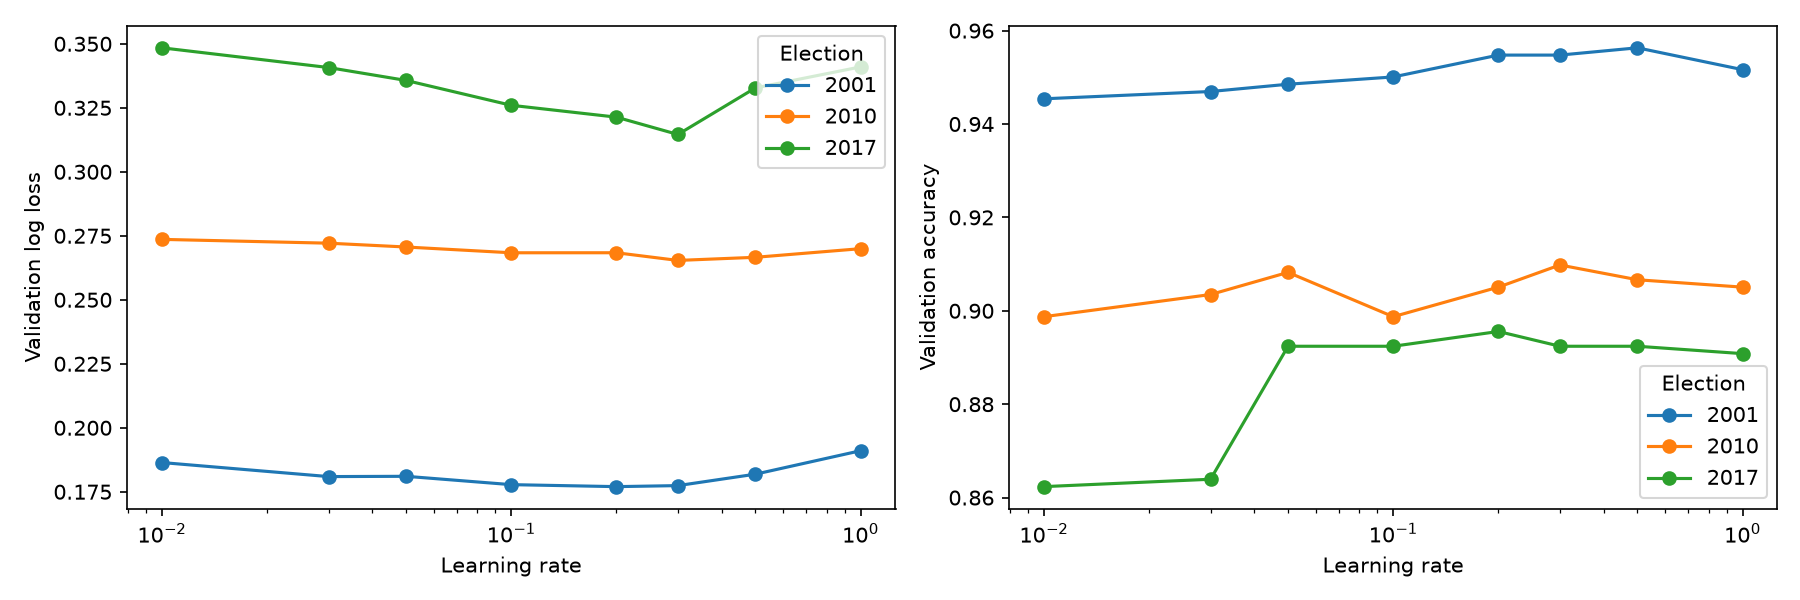

In [6]:
validation_results = pd.DataFrame(validation_records)
training_records = pd.DataFrame(run_records)
comparison = validation_results.groupby("learning_rate", sort=False).agg(
    mean_validation_log_loss=("log_loss", "mean"),
    mean_validation_accuracy=("accuracy", "mean"),
    worst_election_accuracy=("accuracy", "min"),
    mean_brier_score=("brier_score", "mean"),
    capped_runs=("capped_runs", "sum"),
).sort_values("mean_validation_log_loss", kind="stable")
comparison.to_csv(OUTPUT_DIR / "learning_rate_comparison.csv")
display(comparison)
display(validation_results)
display(training_records.groupby(["validation_year", "learning_rate"]).agg(
    mean_best_epoch=("best_epoch", "mean"), min_best_epoch=("best_epoch", "min"),
    max_best_epoch=("best_epoch", "max"), seed_accuracy_std=("validation_accuracy", "std")))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for year, group in validation_results.groupby("validation_year"):
    axes[0].plot(group.learning_rate, group.log_loss, marker="o", label=str(year))
    axes[1].plot(group.learning_rate, group.accuracy, marker="o", label=str(year))
for ax, label in zip(axes, ["Validation log loss", "Validation accuracy"]):
    ax.set_xscale("log"); ax.set_xlabel("Learning rate"); ax.set_ylabel(label); ax.legend(title="Election")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "validation_comparison.png", dpi=150)
plt.show()


## Optional next-election development evaluation

Enabled as requested. These are development backtests, including the later pipeline comparison election, 2019. For each window, select a learning rate using **only that window's validation log loss**, then score its ensemble on the next election. Do not use the aggregate learning-rate ranking here: later windows have already seen earlier evaluation outcomes. Once these results are inspected to change the recipe, they are development evidence rather than untouched tests. In particular, inspecting 2019 here spends its value as a fresh later comparison.

In [7]:
if EVALUATE_NEXT_ELECTION:
    evaluation_records = []
    for cutoff, validation_year, evaluation_year in WINDOWS:
        candidates = validation_results.loc[validation_results.train_through == cutoff]
        selected_rate = float(candidates.loc[candidates.log_loss.idxmin(), "learning_rate"])
        fitted = ensembles[(cutoff, selected_rate)]
        evaluation = data.loc[data.election == evaluation_year].copy()
        assert not evaluation.empty
        p = np.mean([probabilities(net, prep, evaluation) for net, prep in fitted["members"]], axis=0)
        evaluation_records.append(dict(train_through=cutoff, validation_year=validation_year,
                                       evaluation_year=evaluation_year, learning_rate=selected_rate,
                                       **scores(evaluation, p, fitted["classes"])))
    evaluation_results = pd.DataFrame(evaluation_records)
    display(evaluation_results)
    evaluation_results.to_csv(OUTPUT_DIR / "next_election_development_results.csv", index=False)
else:
    print("Next-election evaluation disabled. No 2019 or 2024 evaluation performed.")


,train_through,validation_year,evaluation_year,learning_rate,accuracy,changed_seat_accuracy,changed_seats,log_loss,brier_score,rows,unseen_winners
0,2015,2017,2019,0.3,0.901899,0.355263,76,0.243704,0.142491,632,0
1,2005,2010,2015,0.3,0.787975,0.128440,109,0.789720,0.332938,632,0
2,1997,2001,2005,0.2,0.788217,0.614035,57,0.470875,0.279784,628,0


## Using this work later

After reviewing these development results, freeze the architecture, preprocessing, seed ensemble and learning-rate selection rule. The proposed pipeline selection stage would then train through 2015, early-stop on all of 2017, and compare candidates on 2019. Compare model families on identical evaluation rows and a predetermined criterion. This notebook makes no pipeline changes. It also makes no claim that differences across three correlated historical windows establish statistical superiority.